In [2]:
!pip3 uninstall -y torch torchvision
!pip3 install torch torchvision

Found existing installation: torch 2.1.0
Uninstalling torch-2.1.0:
  Successfully uninstalled torch-2.1.0
Found existing installation: torchvision 0.15.2a0
Uninstalling torchvision-0.15.2a0:
  Successfully uninstalled torchvision-0.15.2a0
  Obtaining dependency information for torchvision from https://files.pythonhosted.org/packages/23/19/55b28aecdc7f38df57b8eb55eb0b14a62b470ed8efeb22cdc74224df1d6a/torchvision-0.25.0-cp311-cp311-win_amd64.whl.metadata
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.0 MB 991.0 kB/s eta 0:00:05
   - -------------------------------------- 0.2/4.0 MB 1.8 MB/s eta 0:00:03
   --- ------------------------------------ 0.3/4.0 MB 2.4 MB/s eta 0:00:02
   ---- ----------------------------------- 0.5/4.0 MB 2.9 MB/s eta 0:00:02
   -------- ------------------------------- 0.9/4.0 MB 3.9 MB/s eta 0:00:01
   ------------- -------------------------- 1.4/4.0 MB 5.2 MB/s eta 0:00:01
   --------------

In [ ]:
!pip uninstall numpy
!pip install "numpy<2.0"

In [3]:
!pip install --upgrade torch

  Obtaining dependency information for torch from https://files.pythonhosted.org/packages/6f/3d/c87b33c5f260a2a8ad68da7147e105f05868c281c63d65ed85aa4da98c66/torch-2.10.0-cp311-cp311-win_amd64.whl.metadata
  Using cached torch-2.10.0-cp311-cp311-win_amd64.whl.metadata (31 kB)
Using cached torch-2.10.0-cp311-cp311-win_amd64.whl (113.7 MB)
  Attempting uninstall: torch
    Found existing installation: torch 2.1.0
    Uninstalling torch-2.1.0:
      Successfully uninstalled torch-2.1.0


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
import torch
from torch import nn
from torch import optim

In [13]:
# Целевая функция x * sin(x) + c

In [14]:
#!pip3 install https://download.pytorch.org/whl/cpu/torch-1.1.0-cp36-cp36m-linux_x86_64.whl
#!pip3 install https://download.pytorch.org/whl/cpu/torchvision-0.3.0-cp36-cp36m-linux_x86_64.whl

In [15]:
# numpy==1.26.4
# pip install pandas==2.2.0
# pip install --upgrade pandas

In [18]:
def g(x):
    C = 100
    return x**2 * np.sin(x) + C

def y(x):
    sigma = 2
    eps = torch.normal(0, sigma, x.shape)
    return g(x) + eps

In [19]:
X = torch.arange(0, 5, 0.01)
Y = y(X)

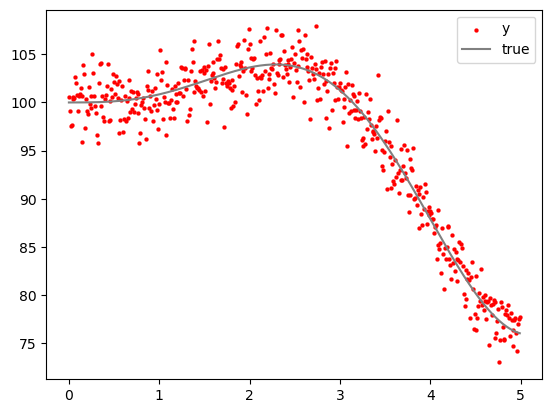

In [20]:
plt.scatter(X, Y, label="y", c="r", marker='.', linewidths=0.1)
plt.plot(X, g(X), label="true", c="gray")
plt.legend()

In [21]:
# Train-Test split
idx = list(range(len(X)))
np.random.shuffle(idx)

k = 0.7

train_idx, test_idx = idx[: int(len(idx) * k)], idx[int(len(idx) * k) :]


In [22]:
# Модель - линейная рекгрессия
models = {
    i : nn.Linear(i, 1)
    for i in range(1, 8)
}


In [23]:
# MSE Loss
loss = nn.MSELoss()


In [24]:
# Генерация 1000 обучающих выборок
train_idxs = []

for _ in range(1000):
    idx = list(range(len(X)))
    np.random.shuffle(idx)
    
    train_idx = idx[: int(len(X) * 0.7)]

    train_idxs.append(train_idx)


In [25]:
# Генерациф случайных тестовых выборок
idx = list(range(len(X)))
np.random.shuffle(idx)

test_idx = idx[: int(len(X) * 0.3)]


In [ ]:
# Обучение моделей на всех подвыборках
pred = {}
num_epochs = 20

for d, model in models.items():
    
    pred[d] = []
    y_test = Y[test_idx]
    X_test = torch.Tensor(len(test_idx), d)
    
    for i in range(d):
        X_test[:, i] = X[test_idx] ** (i + 1)
        
    for train_idx in train_idxs:
        
        optimizer = optim.Adam(model.parameters(), lr = 0.01)
        
        X_train = torch.Tensor(len(train_idx), d)
        y_train = Y[train_idx]
        
        for i in range(d):
            X_test[:, i] = X[test_idx] ** (i + 1)
            
        for train_idx in train_idxs:
            
            optimizer = optim.Adam(model.parameters(), lr=0.01)
            
            X_train = torch.Tensor(len(train_idx), d)
            y_train = Y[train_idx]
            
            for i in range(d):
                X_train[:, i] = X[train_idx] ** (i + 1)
                
            # model train loop
            for epoch in range(num_epochs):
                
                optimizer.zero_grad()
                
                y_pred = model(X_train).squeeze()
                error = loss(y_pred, y_train)
                
                error.backward()
                optimizer.step()
                
            error = loss(model(X_test).squeeze(), y_test)
            pred[d].append(model(X_test).squeeze().detach().numpy())
        
    
    


In [ ]:
# Визцуализация обученных моделей
from matplotlib import cm

fig = plt.figure()
ax = fig.add_subplot(111)

for i, (d, model) in enumerate(models.items()):
    color = cm.viridis_r.colors[i * len(cm.viridis_r.colors) // len(models)]
    
    
    X_test = torch.Tensor(len(test_idx), d)
    
    for i in range(d):
        X_test[:, i] = X[test_idx] ** (i + 1)
        
    y_pred = model(X_test).squeeze()
    ax.scatter(X[test_idx], y_pred.tolist(), color=color, marker=".", label=f"d = {d}", alpha=0.5)
    
    
ax.set_xlabel('x')
ax.scatter(X[test_idx], Y[test_idx].tolist(), c='r', marker='.', label="f(x)")
ax.plot(X, g(X), c='gray', marker='.', label="g(X)")
plt.legend()


In [ ]:
# Вычисление смещения и дисперсии по обучающим выборкам

In [ ]:
bias_sq = {
    i : np.mean((g(X[test_idx]).numpy() - np.mean(pred[i], axis=0)) ** 2)
    for i in models.keys()
}

var = {
    i : np.array(pred[i]).var(axis=0).mean()
    for i in models.keys()
}


In [ ]:
from mmatplotlib import cm

fig = plt.figure()
ax = fig.add_subplot(111)

ax.set_xlabel('d')

ax.plot(list(bias_sq.keys()), list(bias_sq.values()), c='b', label="$bias^2$")
ax.plot(list(var.keys()), list(var.values()), c='g', label="Var")

plt.legend()